<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/last_resort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install vaderSentiment
import pandas as pd
import numpy as np
import matplotlib as plt
import re
import random

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import RegexpTokenizer
# nltk imports
from nltk.tokenize import word_tokenize  # tokenize the text == the text is splitted into words in list
from nltk.corpus import stopwords  # this contain common stop words that has no effect in analysis
from nltk.stem import WordNetLemmatizer  # Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item

# download nltk corpus (first time only)
import nltk

nltk.download('all')



[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package basque_grammars is already up-to-date!
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    |   Package bcp47 is already up-to-dat

True

In [14]:
df = pd.read_csv('esg_documents_for_dax_companies.csv', delimiter = '|', index_col = 0)

In [15]:
# Sorting dataframe by companies in alphabetical order
df = df.sort_values('company', ascending=True)
# Now we can properly reset the index
df = df.reset_index(drop=True)
df.head(10)


,company,content,datatype,date,domain,esg_topics,internal,symbol,title,url
0,Adidas AG,"Since March 2021, Puerto Rican musician Benito...",general,2022-04-21,teenvogue,['Privacy'],0,ADS,Bad Bunny Teased a New Pair of His Own Adidas ...,https://www.teenvogue.com/story/bad-bunny-baby...
1,Adidas AG,Quarterback Jalen Hurts has agreed to a five-y...,business,2023-04-17,marketwatch,['GenderDiversity'],0,ADS,Agent who got Jalen Hurts a $ 255 million deal...,https://www.marketwatch.com/story/the-real-win...
2,Adidas AG,Bradley Simmonds is the hot new trainer whippi...,tech,2022-07-21,metro.co,"['Heatwave', 'Social']",0,ADS,Instagram PT Bradley Simmonds says use superse...,https://metro.co.uk/2022/07/21/instagram-pt-br...
3,Adidas AG,"Welcome back to How I Made It, Metro.co.uk’ s ...",tech,2022-08-06,metro.co,"['Renumeration', 'Social']",0,ADS,How I Made It: ' I failed my A-Levels but now ...,https://metro.co.uk/2022/08/06/how-i-made-it-i...
4,Adidas AG,We’ re on the cusp of a season change with sum...,tech,2022-08-31,metro.co,"['Environment', 'Recycling']",0,ADS,The Fit List: Change season with some late sum...,https://metro.co.uk/2022/08/31/the-fit-list-ch...
5,Adidas AG,NEW YORK — Former Vice President Mike Pence on...,business,2022-11-28,marketwatch,"['Racism', 'Social', 'Antisemitism']",0,ADS,'Profoundly poor judgment ': Pence calls on Tr...,https://www.marketwatch.com/story/profoundly-p...
6,Adidas AG,All products featured on Teen Vogue are indepe...,general,2022-03-25,teenvogue,"['Transparency', 'Social', 'Privacy']",0,ADS,"The Best Spring Shoes for 2022, According to Y...",https://www.teenvogue.com/story/the-best-sprin...
7,Adidas AG,"After walking away from Kanye West last year, ...",business,2023-03-08,marketwatch,"['Earthquake', 'Antisemitism']",0,ADS,Adidas has piles of Kanye West's Yeezy shoes a...,https://www.marketwatch.com/story/adidas-has-p...
8,Adidas AG,"LONDON — April 20, 2022 — Hypetex, the market ...",general,2022-04-20,textileworld,['WaterPollution'],0,ADS,Hypetex® To Showcase Colored Carbon And Flax F...,https://www.textileworld.com/textile-world/non...
9,Adidas AG,Amazon Fashion announced the launch of Virtual...,tech,2022-06-10,aithority,['Social'],0,ADS,Amazon Fashion Introduces a More Convenient Wa...,https://aithority.com/technology/sales-and-cus...


In [16]:
df['esg_topics'] = df['esg_topics'].str.replace("[", "")
df['esg_topics'] = df['esg_topics'].str.replace("]", "")

filtered_df = df[df['internal'] == 0]

columns_to_drop = ['date', 'internal', 'title', 'url']
filtered_df.drop(columns=columns_to_drop, inplace=True)

<ipython-input-16-9395b3810a0a>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['esg_topics'] = df['esg_topics'].str.replace("[", "")
<ipython-input-16-9395b3810a0a>:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['esg_topics'] = df['esg_topics'].str.replace("]", "")
<ipython-input-16-9395b3810a0a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.drop(columns=columns_to_drop, inplace=True)


In [17]:
df_sentences = filtered_df[['company','content']].copy()

#df_sentences_sample = df_sentences.sample(n = 20)
#df_sentences_sample = df_sentences_sample.reset_index(drop = True)
#df_sentences_sample


In [18]:
nltk.download('wordnet')

# Initialize a lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Check if the input is a string
    if not isinstance(text, str):
        return ''

    # First we'll use regular expressions to strip out web site adresses
    text = re.sub(r'http[a-zA-Z0-9\&\?\=\?\/\:\.]+\b', ' ', text)
    text = re.sub(r'\<[^\<\>]+\>', ' ', text)
    # Next, let's clear out all punctuation and replace it with whitespace
    text = re.sub(r'\W+', ' ', text)
    # And clear out numbers
    text = re.sub(r'[0-9]+', ' ', text)
    # And then lowercase
    text = text.lower()


    # Next, let's split on whitespace and then lemmatize each token
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(x) for x in tokens]
    text = " ".join(tokens)

    return text


df_sentences['content_clean'] = df_sentences['content'].map(clean_text)
df_sentences['content_clean'].values

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


array(['since march puerto rican musician benito antonio martínez ocasio better known by his stage name bad bunny ha been producing footwear with adidas the year old reggaeton star and adidas announced early last year that they would embark on a long term partnership that will see u work on a number of collaborative project and product drop over the coming season to date the partnership ha comprised a single silhouette the adidas forum low characterized by a buckle lace crossover and chunky construction the sneaker have also been reworked by adidas partner beyoncé and kerwin frost so far bad bunny and the german brand have served a pair of deliciously palatable beige off white and brown first café coffee inspired adidas forum buckle low a well a a baby pink easter egg iteration of the shoe following those release in august bunny dropped the forum back to school which wa a chunky all black everything design each sneaker release ha been a huge success the kick sold out instantly upon the

In [20]:
# Download necessary nltk data
nltk.download('stopwords')
nltk.download('punkt')

stop_words_nltk = stopwords.words('english')

# Create a function to remove stopwords and tokenize
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    tokens = nltk.word_tokenize(text)
    filtered_tokens= [word for word in tokens if word not in stop_words]
    filtered_text = ' '.join(filtered_tokens)
    return filtered_text


df_sentences['content_clean'] = df_sentences['content_clean'].astype(str)
df_sentences.dropna(subset=['content_clean'], inplace=True)


df_sentences['content_tokens'] = df_sentences['content_clean'].apply(remove_stopwords)

df_sentences.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,company,content,content_clean,content_tokens
0,Adidas AG,"Since March 2021, Puerto Rican musician Benito...",since march puerto rican musician benito anton...,since march puerto rican musician benito anton...
1,Adidas AG,Quarterback Jalen Hurts has agreed to a five-y...,quarterback jalen hurt ha agreed to a five yea...,quarterback jalen hurt ha agreed five year mil...
2,Adidas AG,Bradley Simmonds is the hot new trainer whippi...,bradley simmonds is the hot new trainer whippi...,bradley simmonds hot new trainer whipping fitn...
3,Adidas AG,"Welcome back to How I Made It, Metro.co.uk’ s ...",welcome back to how i made it metro co uk s we...,welcome back made metro co uk weekly career jo...
4,Adidas AG,We’ re on the cusp of a season change with sum...,we re on the cusp of a season change with summ...,cusp season change summer slipping away autumn...


In [21]:
analyser = SentimentIntensityAnalyzer()

In [22]:
df_sentences['Scores'] = df_sentences['content_tokens'].apply(lambda Sentence: analyser.polarity_scores(Sentence)['compound'])
df_sentences

,company,content,content_clean,content_tokens,Scores
0,Adidas AG,"Since March 2021, Puerto Rican musician Benito...",since march puerto rican musician benito anton...,since march puerto rican musician benito anton...,0.9919
1,Adidas AG,Quarterback Jalen Hurts has agreed to a five-y...,quarterback jalen hurt ha agreed to a five yea...,quarterback jalen hurt ha agreed five year mil...,0.9612
2,Adidas AG,Bradley Simmonds is the hot new trainer whippi...,bradley simmonds is the hot new trainer whippi...,bradley simmonds hot new trainer whipping fitn...,0.9985
3,Adidas AG,"Welcome back to How I Made It, Metro.co.uk’ s ...",welcome back to how i made it metro co uk s we...,welcome back made metro co uk weekly career jo...,0.9972
4,Adidas AG,We’ re on the cusp of a season change with sum...,we re on the cusp of a season change with summ...,cusp season change summer slipping away autumn...,0.9991
...,...,...,...,...,...
11543,Zalando SE,". If you delight your customers, they’ ll rewa...",if you delight your customer they ll reward yo...,delight customer reward every organization nee...,0.9999
11544,Zalando SE,BoF Professional Fashion’ s favourite term mea...,bof professional fashion s favourite term mean...,bof professional fashion favourite term mean e...,0.9957
11545,Zalando SE,The Chinese ultra-fast fashion giant’ s polici...,the chinese ultra fast fashion giant s policy ...,chinese ultra fast fashion giant policy proces...,0.6199
11546,Zalando SE,"FRANKFURT AM MAIN, Germany — April 29, 2019 — ...",frankfurt am main germany april sustainability...,frankfurt main germany april sustainability te...,0.9983


In [28]:
df_sentences.iloc[16,4]

0.9744

In [29]:
df_sentences.iloc[16,1]

"Forgetting to charge wireless devices has been an issue since they started being made. Headphones and earbuds are no exception. Now the German sports giant Adidas, and the Swedish firm Urbanista, both have solar panels built into the headbands of their headphones. These small, lightweight, flexible panels are built by another Swedish company, Exeger. They have spent the last ten years working to make those panels have the attributes that are thin, and powerful enough to be used in a headphone. Exeger’ s head, Giovanni Fili says it is a matter of matter of convenience and most importantly the right thing to do for the environment. In a statement Fili said, “ Charging – everyone hates it. But every time you don’ t charge [ using main electricity ] it is a good thing for the world. The new generation of young adults expects to be offered the tools to do good [ for the environment ], and that is what we are offering. '' The solar panels that Exeger makes are called Powerfoyle and they are

In [25]:
from google.colab import files
df_sentences.to_csv('lol.csv')
files.download('lol.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
def valuemaker(i):
  if i < -0.5:
    i = -1
  elif i > 0.5:
    i = 1
  else:
    i = 0
  return i

In [31]:
df2 = df_sentences

df2['Scores'] = df2['Scores'].apply(valuemaker)
df2.head()



,company,content,content_clean,content_tokens,Scores
0,Adidas AG,"Since March 2021, Puerto Rican musician Benito...",since march puerto rican musician benito anton...,since march puerto rican musician benito anton...,1
1,Adidas AG,Quarterback Jalen Hurts has agreed to a five-y...,quarterback jalen hurt ha agreed to a five yea...,quarterback jalen hurt ha agreed five year mil...,1
2,Adidas AG,Bradley Simmonds is the hot new trainer whippi...,bradley simmonds is the hot new trainer whippi...,bradley simmonds hot new trainer whipping fitn...,1
3,Adidas AG,"Welcome back to How I Made It, Metro.co.uk’ s ...",welcome back to how i made it metro co uk s we...,welcome back made metro co uk weekly career jo...,1
4,Adidas AG,We’ re on the cusp of a season change with sum...,we re on the cusp of a season change with summ...,cusp season change summer slipping away autumn...,1


<Axes: >

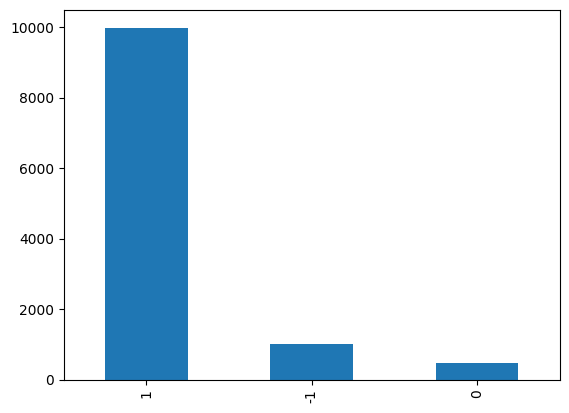

In [32]:
df2.Scores.value_counts().plot.bar()